In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", None)


In [3]:
df = pd.read_excel("Base_de_Leads_limpia.xlsx")
df.head()


,Fecha de Alta,Mes Lead,ID_Lead,Titulo,Nombre,Producto,Temperatura,Comentario,Asesor,Fuente,Origen,Estatus
0,2025-11-30 08:38:00,11,834956f716e7ddae82527bf81c29ebc8,Lead ANGE,Apolonio Torres Perez,EMZOOM,Lead Muy Interesado,Se reactiva lead para captura de ventaFinal:EM...,CESAR DE JESUS PESTAÑA,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
1,2025-11-29 21:17:00,11,13ee2f21ed8506825e8591bf1abdab51,Lead ANGE,Javier Nieto,GS4 MAX,Lead Interes Medio,SE LE CONTACTA EN PLAZA ANGELOPOLIS Final:GS4 ...,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Finalizado
2,2025-11-29 20:48:00,11,fad33b39f526b4ebe04a4b7e86002d5a,Lead ANGE,Ismael Segovia Banos,GS4 MAX,Lead Muy Interesado,SE INTERESA POR GS4 Final:GS4 MAX HEV,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
3,2025-11-29 16:11:00,11,e495cd540b7c7dc55b516fbdc7ea8bf0,Lead ANGE,Luis Jaime Estrada,EMKOO,Lead Muy Interesado,ofrecí también GS4 y emko hv Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado
4,2025-11-29 16:08:00,11,4d2b212032284fa42fa64a493e34c4ed,Lead ANGE,Hector Hamley,EMKOO,Lead Interes Medio,interés Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado


Esta fue una sugerencia de la IA, ya al ser una base de comentarios, como tal no es posible hacer una regresión líneal

In [4]:
print("Meses distintos en esta base:", df['Mes Lead'].nunique())
print("Valor(es):", df['Mes Lead'].unique())
print("Rango de fechas:", df['Fecha de Alta'].min(), "→", df['Fecha de Alta'].max())


Meses distintos en esta base: 1
Valor(es): [11]
Rango de fechas: 2025-11-02 12:09:00 → 2025-11-30 08:38:00


Esta base cubre un solo mes (noviembre 2025, 210 leads individuales), no 28 meses agregados.
No existe variación mes a mes que regresionar (Mes Lead es una constante) así que el modelo no es replicable con estos datos, no es un problema
del método, es que la unidad de análisis (mes) no varía dentro de este archivo.


In [5]:
df['dia'] = df['Fecha de Alta'].dt.date

prueba_diaria = df.groupby('dia').agg(
    total_leads=('ID_Lead', 'count'),
    ventas=('Estatus', lambda s: (s == '1 Ventas').sum()),
).reset_index()
prueba_diaria['tasa_venta'] = prueba_diaria['ventas'] / prueba_diaria['total_leads'] * 100

r, p = stats.pearsonr(prueba_diaria['total_leads'], prueba_diaria['tasa_venta'])
print(f"Volumen diario de leads vs. tasa de venta diaria: r = {r:.3f}, p = {p:.3f}  (n = {len(prueba_diaria)} días)")


Volumen diario de leads vs. tasa de venta diaria: r = -0.211, p = 0.321  (n = 24 días)


Con p ≈ 0.32, por lo que no hay relación estadísticamente significativa entre el volumen diario de leads y la tasa de venta diaria en esta base.


In [6]:
fecha_corte = df['Fecha de Alta'].max().normalize()
df['antiguedad_dias'] = (fecha_corte - df['Fecha de Alta'].dt.normalize()).dt.days

agg = df.groupby('dia').agg(
    total_leads=('ID_Lead', 'count'),
    finalizados=('Estatus', lambda s: (s == 'Finalizado').sum()),
    antiguedad_dias=('antiguedad_dias', 'first'),
).reset_index()
agg['tasa_finalizado'] = agg['finalizados'] / agg['total_leads'] * 100

agg[['dia', 'antiguedad_dias', 'total_leads', 'tasa_finalizado']].sort_values('antiguedad_dias')


,dia,antiguedad_dias,total_leads,tasa_finalizado
23,2025-11-30,0,1,0.000000
22,2025-11-29,1,6,33.333333
21,2025-11-28,2,4,0.000000
20,2025-11-27,3,21,28.571429
19,2025-11-26,4,10,30.000000
18,2025-11-25,5,3,100.000000
17,2025-11-24,6,13,15.384615
16,2025-11-22,8,1,100.000000
15,2025-11-20,10,5,60.000000
14,2025-11-19,11,8,37.500000


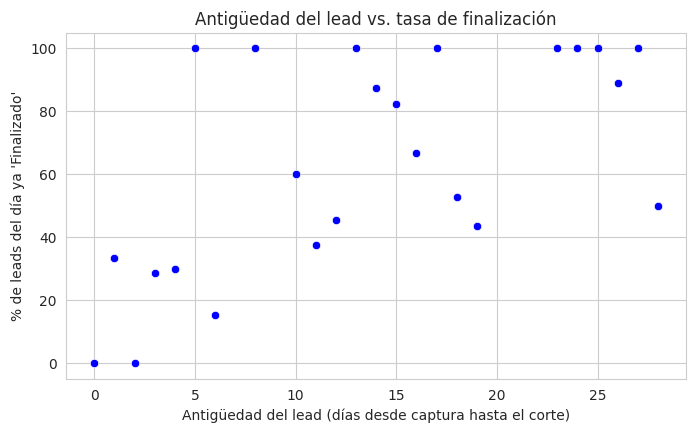

In [7]:
#Imprimimos el scatter plot entre la variable dependiente (tasa_finalizado) e independiente (antiguedad_dias)
#para observar el comportamiento en su dispersión
sns.scatterplot(x='antiguedad_dias', y='tasa_finalizado', color="blue", data=agg)
plt.xlabel("Antigüedad del lead (días desde captura hasta el corte)")
plt.ylabel("% de leads del día ya 'Finalizado'")
plt.title("Antigüedad del lead vs. tasa de finalización")
plt.show()


# Ajuste del modelo

In [8]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep = agg[['antiguedad_dias']]
Var_Dep = agg['tasa_finalizado']


In [9]:
#Se define model como la función de regresión lineal
model = LinearRegression()


In [10]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)


LinearRegression()

In [11]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__


{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['antiguedad_dias'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([2.42269953]),
 'rank_': 1,
 'singular_': array([42.46910642]),
 'intercept_': np.float64(30.421702112475984)}

In [12]:
print(f"Modelo matemático: tasa_finalizado = {model.coef_[0]:.4f} * antiguedad_dias + {model.intercept_:.4f}")


Modelo matemático: tasa_finalizado = 2.4227 * antiguedad_dias + 30.4217


Podemos decir que por cada día adicional de antigüedad, el porcentaje de leads de ese día que ya llegó a Finalizado aumenta, en promedio, 2.42 puntos porcentuales. Un día recién capturado (antigüedad 0) arranca, en
promedio, con un 30.4% ya finalizado (probablemente contactos que se resuelven casi de inmediato, "no interesado" en el primer contacto).


In [13]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep, Var_Dep)


0.3839311726199863

In [14]:
#Predecimos la tasa de finalización a partir de la antigüedad del lead
y_pred = model.predict(X=agg[['antiguedad_dias']])
y_pred


array([98.25728886, 95.83458933, 93.41188981, 90.98919028, 88.56649075,
       86.14379123, 76.45299312, 74.03029359, 71.60759407, 69.18489454,
       66.76219501, 64.33949549, 61.91679596, 59.49409643, 57.07139691,
       54.64869738, 49.80329833, 44.95789927, 42.53519975, 40.11250022,
       37.68980069, 35.26710117, 32.84440164, 30.42170211])

In [15]:
#Insertamos la columna de predicciones en el DataFrame agregado
agg.insert(0, 'Prediccion_tasa_finalizado', y_pred)
agg.sort_values('antiguedad_dias')


,Prediccion_tasa_finalizado,dia,total_leads,finalizados,antiguedad_dias,tasa_finalizado
23,30.421702,2025-11-30,1,0,0,0.000000
22,32.844402,2025-11-29,6,2,1,33.333333
21,35.267101,2025-11-28,4,0,2,0.000000
20,37.689801,2025-11-27,21,6,3,28.571429
19,40.112500,2025-11-26,10,3,4,30.000000
18,42.535200,2025-11-25,3,3,5,100.000000
17,44.957899,2025-11-24,13,2,6,15.384615
16,49.803298,2025-11-22,1,1,8,100.000000
15,54.648697,2025-11-20,5,3,10,60.000000
14,57.071397,2025-11-19,8,3,11,37.500000


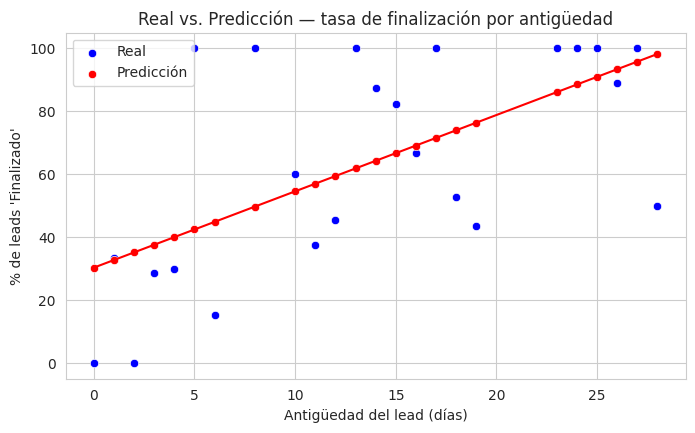

In [16]:
#Visualizamos la gráfica comparativa entre la tasa real y la tasa predicha

sns.scatterplot(x='antiguedad_dias', y='tasa_finalizado', color="blue", data=agg, label="Real")
sns.scatterplot(x='antiguedad_dias', y='Prediccion_tasa_finalizado', color="red", data=agg, label="Predicción")
sns.lineplot(x='antiguedad_dias', y='Prediccion_tasa_finalizado', color="red", data=agg)
plt.xlabel("Antigüedad del lead (días)")
plt.ylabel("% de leads 'Finalizado'")
plt.title("Real vs. Predicción — tasa de finalización por antigüedad")
plt.legend()
plt.show()


In [17]:
#Corroboramos cuál es el coeficiente de Determinación de nuestro modelo
coef_Deter = model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter


0.3839311726199863

In [18]:
#Corroboramos cuál es el coeficiente de Correlación de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
coef_Correl


np.float64(0.6196217980510259)

El modelo explica 38.4% de la variación diaria en la tasa de finalización (R² = 0.384), con una
correlación de 0.62. Para un fenómeno con solo 24 puntos y bastante ruido día a día (algunos días con
apenas 1-4 leads), es una relación considerablemente sólida y con significancia estadística
(p = 0.0012, calculada en la sección 1 con la misma lógica).


## Relaciones adicionales entre las variables agregadas

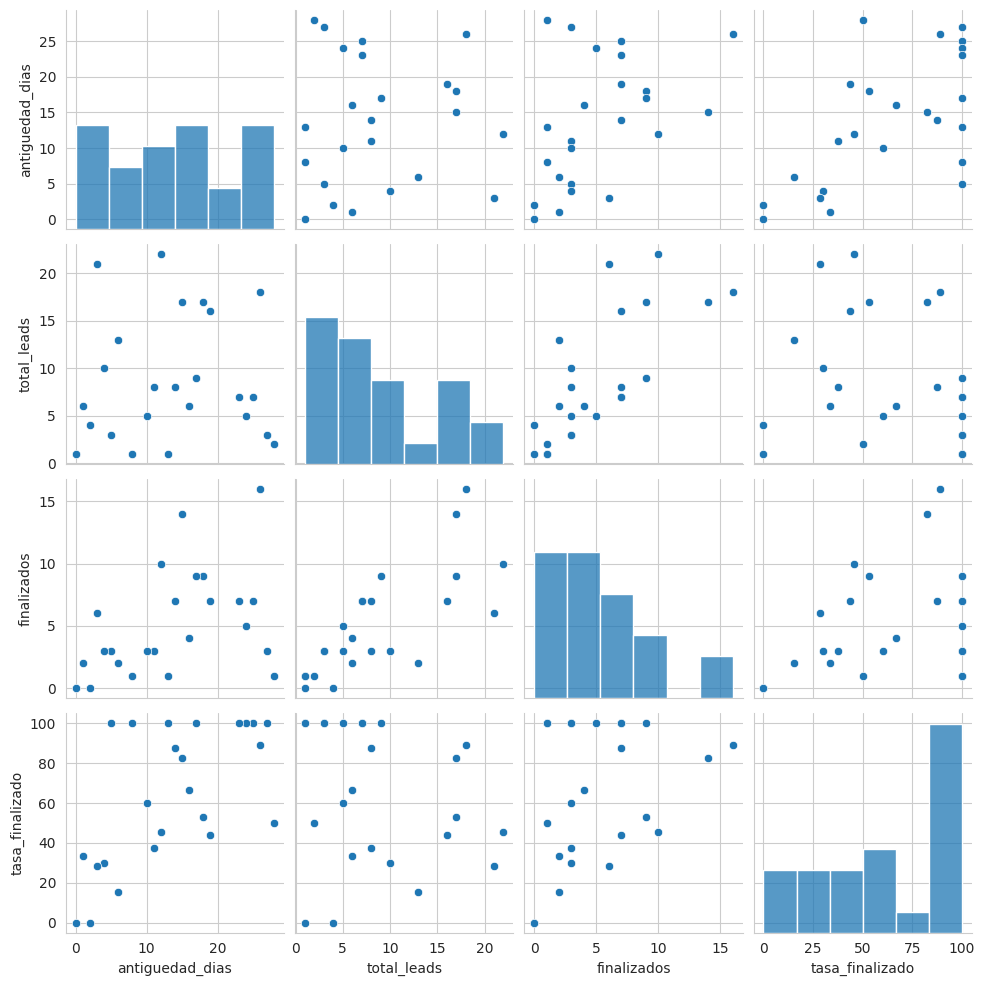

In [19]:
#Graficamos todas las dispersiones entre las variables numéricas derivadas
variables_num = agg[['antiguedad_dias', 'total_leads', 'finalizados', 'tasa_finalizado']]
sns.pairplot(variables_num)
plt.show()


In [20]:
#Encontramos todas las correlaciones entre las variables
Corr_Factors = variables_num.corr()
Corr_Factors


,antiguedad_dias,total_leads,finalizados,tasa_finalizado
antiguedad_dias,1.000000,0.044089,0.449905,0.619622
total_leads,0.044089,1.000000,0.743299,-0.195867
finalizados,0.449905,0.743299,1.000000,0.353077
tasa_finalizado,0.619622,-0.195867,0.353077,1.000000


In [21]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables
Corr_Factors1 = abs(Corr_Factors)
Corr_Factors1


,antiguedad_dias,total_leads,finalizados,tasa_finalizado
antiguedad_dias,1.000000,0.044089,0.449905,0.619622
total_leads,0.044089,1.000000,0.743299,0.195867
finalizados,0.449905,0.743299,1.000000,0.353077
tasa_finalizado,0.619622,0.195867,0.353077,1.000000


<Axes: >

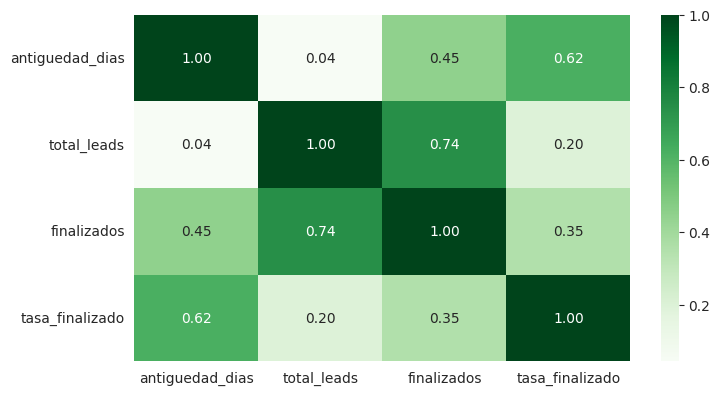

In [22]:
#Graficamos el mapa de calor de los coeficientes de correlación
Heat_Map = sns.heatmap(Corr_Factors1, cmap='Greens', annot=True, fmt=".2f")
Heat_Map


## Descargar la tabla usada en el modelo


In [ ]:
RUTA_SALIDA = "Regresion_Base_Leads_diario.csv"
agg.sort_values('antiguedad_dias').to_csv(RUTA_SALIDA, index=False)
print(f"Tabla exportada a: {RUTA_SALIDA}")


Tabla exportada a: Regresion_Base_Leads_diario.csv


In [ ]:
# Si el notebook se ejecuta en Google Colab, esta celda descarga el archivo al equipo.
# En un entorno local/Jupyter normal, el archivo ya quedó guardado en la ruta de arriba.
try:
    from google.colab import files
    files.download(RUTA_SALIDA)
except ImportError:
    print("No estás en Google Colab: el archivo ya está guardado localmente en", RUTA_SALIDA)


No estás en Google Colab: el archivo ya está guardado localmente en Regresion_Base_Leads_diario.csv
